In [1]:
import numpy
from os.path import join
import matplotlib.pyplot as plt
import colorsys
import texplot

from freealg import AlgebraicForm
from freealg.distributions import \
    MarchenkoPastur, ChiralBlock, DeformedWigner, \
    DeformedMarchenkoPastur, CompoundFreePoisson, FreeLevy

plot_dir = './plots'

# Option 1. Marchenko-Pastur Model

* This has two sheets $s=2$ and one cut $k=1$.
* Corresponding compact geometry is a Riemann sphere $\mathbb{S}^2$.

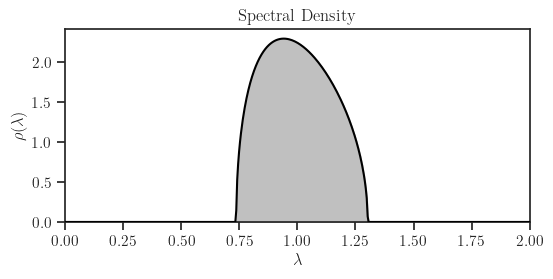

In [2]:
filename = 'mp'
title = 'Marchenko-Pastur Model'
save_filename = 'mp'

sigma = 1.0
lam = 100 / 5000

mp = MarchenkoPastur(lam, sigma)
support = mp.support()
a1, b1 = support[0]

# Grid for MP
x_min, x_max = -0.5, 2.5
y_min, y_max = -1.0, 1.0

_ = mp.density(plot=True, latex=True, save=False)

# Option 2. Chiral Block

* This has two sheets $s=2$ and two cuts $k=2$.
* Corresponding compact geometry is a torus $\mathbb{T}^1$.

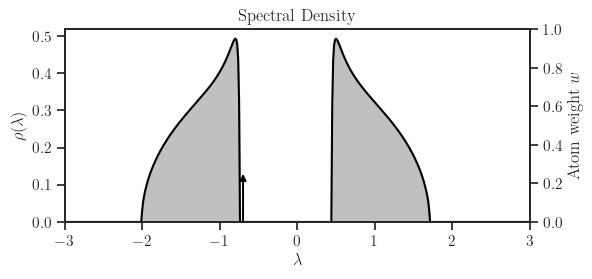

In [12]:
filename = 'cb'
title = 'Chiral Block Model'
save_filename = 'cb'

alpha = 0.40
beta = -0.70
c = 0.6

cb = ChiralBlock(alpha, beta, c)

# Support
support = cb.support()

# Grid for bipartite
x_min, x_max = -3.0, 3.0
y_min, y_max = -2.0, 2.0

_ = cb.density(plot=True, latex=True, save=False)

# Option 3. Deformed Wigner Model

* This has three sheets $s=3$ and two cuts $k=2$.
* Corresponding compact geometry is still a Riemann sphere $\mathbb{S}^2$.

[(-2.6664926899770567, -0.7147737555874724), (0.8478632229082883, 4.283403222656241)]


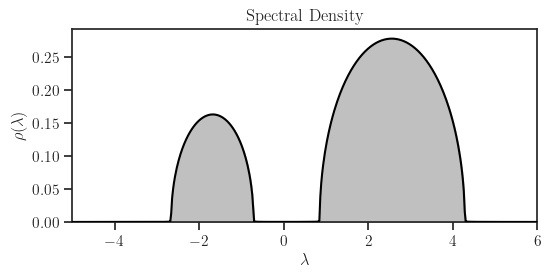

In [12]:
filename = 'dwg'
title = 'Deformed Wigner Model'
save_filename = 'dwg'

sigma = 1.0
t1 = -1.5
t2 = 2.5
w1 = 0.25

dwg = DeformedWigner(t=[t1, t2], w=[w1, 1-w1], sigma=sigma)

# Support
support = dwg.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dwg.density(plot=True, latex=True, save=False)

# Option 4. Deformed Marchenko-Pastur Model

* This has three sheets $s=3$ and two cuts $k=2$.
* Corresponding compact geometry is still a Riemann sphere $\mathbb{S}^2$.

[(1.271942644768898, 2.796717409578293), (4.465954791747979, 6.910028011047688)]


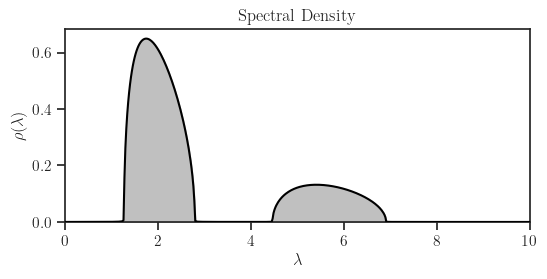

In [10]:
filename = 'dmp'
title = 'Deformed Marchenko-Pastur Model'
save_filename = 'dmp'

c = 0.05
t1 = 2.0
t2 = 5.5
w1 = 0.75

dmp = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=c)

# Support
support = dmp.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 2.0)
x_max = numpy.ceil(max(b for a, b in support) + 2.0)
y_min, y_max = -3.0, 3.0

_ = dmp.density(plot=True, latex=True, save=False)

# Option 5. Compound Free Poisson Model

* This has three sheets $s=3$ and two cuts $k=2$.

[(0.9984996249062267, 3.13165791447862), (4.157389347336835, 7.597674418604652)]


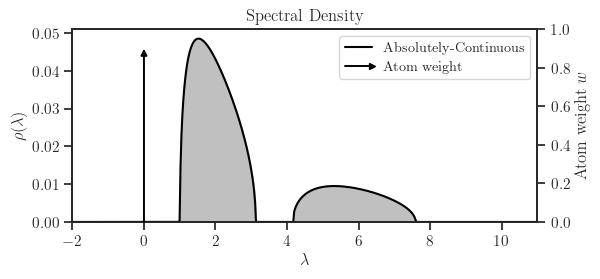

In [3]:
filename = 'cfp'
title = 'Compound Free Poisson'
save_filename = 'cfp'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

cfp = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)

# Support
support = cfp.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = cfp.density(plot=True, latex=True, save=False)

# Option 6. Free Levy Model

* This has three sheets $s=3$ and two cuts $k=2$.

[(-0.8032258064516131, 0.7838709677419353), (1.1129032258064515, 3.193548387096774), (4.190322580645161, 7.6161290322580655)]


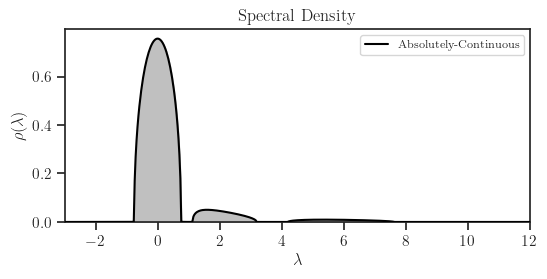

In [2]:
filename = 'fl'
title = 'Free Levy Model'
save_filename = 'fl'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

fl = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0, sigma=0.4)

# Support
support = fl.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = fl.density(plot=True, latex=True, save=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-branches-no-tile.pdf".


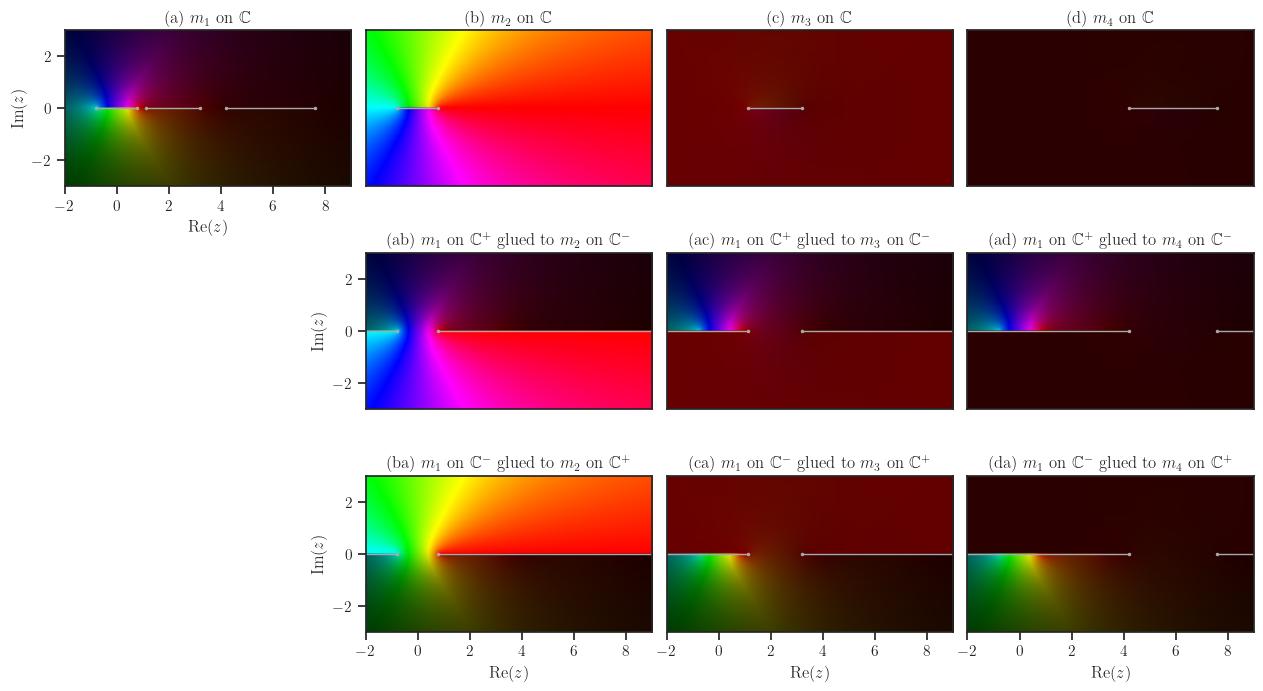

In [8]:
x = numpy.linspace(x_min, x_max, 400)
y = numpy.linspace(y_min, y_max, 400)
fl.plot_branches(x, y, tile_mix=0.0, latex=True,
                 save=join(plot_dir, save_filename + '-branches-no-tile.pdf'))

# Compare Domain Coloring

In [3]:
from freealg.visualization._sheets_util import infer_m1_partners_on_cuts, build_sheets_from_roots
from freealg.visualization._glue_util import glue_branches
from freealg.visualization._domain_coloring import domain_coloring
from freealg.visualization._plot_util import _plot_branch
import matplotlib
import matplotlib.transforms as mtransforms                                   
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker


# ===============
# value formatter
# ===============

def value_formatter(v, pos):
    # v is the normalized "value" channel: v = 1 - exp(-|m(z)|)
    # Invert the mapping: |m(z)| = -ln(1-v)
    if v >= 1:
        return r'$\infty$'
    elif v == 0:
        return r'0'
    else:
        m_val = -numpy.log(1 - v)
        return f"{m_val:.1f}"


# =============
# plot branches
# =============

def compare_domain_coloring(z, m1, roots, support, order='updown', sheet_idx=1,
                            latex=False, save=False, **kwargs):
    """
    Plot branches of the spectral curve of Stieltjes transform.

    Parameters
    ----------

    x : numpy.array, default=None
        The x axis of the grid where the Stieltjes transform is evaluated.

    y : numpy.array, default=None
        The y axis of the grid where the Stieltjes transform is evaluated.

    latex : bool, default=False
        If `True`, the plot is rendered using LaTeX. This option is
        relevant only if ``plot=True``.

    save : bool, default=False
        If not `False`, the plot is saved. If a string is given, it is
        assumed to the save filename (with the file extension). This option
        is relevant only if ``plot=True``.

    **kwargs : dict
        Parameters to pass to :func:`freealg.visualization.domain_coloring`.
    """

    # Defaults to pass to domain_coloring function
    kwargs.setdefault('n_mod', 18)
    kwargs.setdefault('n_ph', 18)
    kwargs.setdefault('vmin', 0.35)
    kwargs.setdefault('vmax', 1.0)
    kwargs.setdefault('tile_gamma', 0.9)
    kwargs.setdefault('tile_mix', 1.0)
    kwargs.setdefault('shift', 0.0)

    if z.shape[0] % 2 != 0:
        raise ValueError('Size of along "y" axis should be even.')

    sheets, _ = build_sheets_from_roots(z, roots, m1, cuts=support)
    m1 = sheets[0]
    n_sheets = len(sheets)

    if n_sheets < 1:
        raise ValueError('No sheets were constructed from roots.')

    # Partners lists, for each cut I_i, the non-physical sheet index that pairs
    # with m1 across that cut. Reorder non-physical sheets to follow cut order.
    partners = infer_m1_partners_on_cuts(z, sheets, support)
    ordered_nonphys = []
    for k in partners:
        if k not in ordered_nonphys:
            ordered_nonphys.append(k)
    for k in range(1, n_sheets):
        if k not in ordered_nonphys:
            ordered_nonphys.append(k)
    sheets = [sheets[0]] + [sheets[k] for k in ordered_nonphys]
    m1 = sheets[0]

    # Remap partner indices after reordering.
    old_to_new = {0: 0}
    for new_k, old_k in enumerate(ordered_nonphys, start=1):
        old_to_new[old_k] = new_k
    partners = [old_to_new[k] for k in partners]

    # Compute cut segments for each non-physical sheet on each support interval
    xline = z[0, :].real

    ycol = z[:, 0].imag
    pos = numpy.where(ycol > 0.0)[0]
    neg = numpy.where(ycol < 0.0)[0]
    if pos.size == 0 or neg.size == 0:
        raise ValueError('Grid must include both positive and negative Im(z).')

    i_up = int(pos[0])     # closest row above real axis
    i_dn = int(neg[-1])    # closest row below real axis

    cut_segments = {k: [] for k in range(1, n_sheets)}

    for (a, b) in support:
        mask = (xline >= float(a)) & (xline <= float(b))
        idx = numpy.where(mask)[0]
        if idx.size == 0:
            continue

        # pick partner of m1 along this interval (piecewise)
        D = []
        for k in range(1, n_sheets):
            Dk = (numpy.abs(sheets[0][i_up, idx] - sheets[k][i_dn, idx]) +
                  numpy.abs(sheets[0][i_dn, idx] - sheets[k][i_up, idx]))
            D.append(Dk)

        D = numpy.vstack(D)  # (n_sheets-1, n_idx)
        K = numpy.argmin(D, axis=0) + 1  # partner in {1..n_sheets-1}

        # compress consecutive equal partners into segments
        seg_start = idx[0]
        for t in range(1, idx.size):
            if K[t] != K[t - 1]:
                k_partner = int(K[t - 1])
                cut_segments[k_partner].append(
                    (float(xline[seg_start]), float(xline[idx[t - 1]])))
                seg_start = idx[t]

        k_partner = int(K[-1])
        cut_segments[k_partner].append(
            (float(xline[seg_start]), float(xline[idx[-1]])))

    # For each non-physical sheet, list the cuts where it partners with m1.
    partner_cuts = {k: [] for k in range(1, n_sheets)}
    for i_cut, k in enumerate(partners, start=1):
        partner_cuts[k].append(i_cut)

    # Extent
    x_min = numpy.min(z[0, :].real)
    x_max = numpy.max(z[0, :].real)
    y_min = numpy.min(z[:, 0].imag)
    y_max = numpy.max(z[:, 0].imag)
    extent = [x_min, x_max, y_min, y_max]

    letters = 'abcdefghijklmnopqrstuvwxyz'
    sheet_letters = letters[:n_sheets]  # a,b,c,...

    ncols = n_sheets
    width = max(9.0, 3.2 * ncols)

    with texplot.theme(use_latex=latex):
        # fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(width, 7.2),
        #                        sharey=True)
        fig = plt.figure(figsize=(12, 4))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.2], wspace=0.3)

        # -------------
        k = sheet_idx
        bc_comp = cut_segments[k]
        title = (fr'({sheet_letters[0]}{sheet_letters[k]}) '
                 fr'$m_1$ on $\mathbb{{C}}^+$ glued to '
                 fr'$m_{k+1}$ on $\mathbb{{C}}^-$')

        if order == 'updown':
            m_glue = glue_branches(z, m1, sheets[k])
        elif order == 'downup':
            m_glue = glue_branches(z, sheets[k], m1)

        ax0 = fig.add_subplot(gs[0])
        _plot_branch(ax0, m_glue, extent,
                     support, x_ax=True, y_ax=True, bc=bc_comp,
                     bc_complement=True, title=title, tile_mix=1.0)

        ax1 = fig.add_subplot(gs[1])
        _plot_branch(ax1, m_glue, extent,
                     support, x_ax=True, y_ax=True, bc=bc_comp,
                     bc_complement=True, title=title, tile_mix=0.0)

        ax0.set_title(r'(a) Tiled Domain Coloring')
        ax1.set_title(r'(b) Plain Domain Coloring')

        pos = ax1.get_position()
        cbar_width = 0.013
        pad = 0.013

        gs_cb = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], width_ratios=[1, 1], wspace=0.05)

        # First colorbar
        cax_hue = fig.add_axes([pos.x1 + pad, pos.y0, cbar_width, pos.height])
        norm_hue = matplotlib.colors.Normalize(vmin=-numpy.pi, vmax=numpy.pi)
        cmap_hue = plt.get_cmap('hsv')
        sm_hue = plt.cm.ScalarMappable(norm=norm_hue, cmap=cmap_hue)
        sm_hue.set_array([])
        cb_hue = fig.colorbar(sm_hue, cax=cax_hue)
        cb_hue.set_label(r'$\mathrm{arg}(m(z))$', labelpad=-6)
        cb_hue.set_ticks([-numpy.pi, 0, numpy.pi])
        cb_hue.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])
        
        # Second colorbar
        cax_value = fig.add_axes([pos.x1 + 4.4*pad + cbar_width, pos.y0, cbar_width, pos.height])
        norm_value = matplotlib.colors.Normalize(vmin=0, vmax=1)
        cmap_value = plt.get_cmap('gray')
        sm_value = plt.cm.ScalarMappable(norm=norm_value, cmap=cmap_value)
        sm_value.set_array([])
        cb_value = fig.colorbar(sm_value, cax=cax_value)
        ticks_norm = [0, 1 - numpy.exp(-0.5), 1 - numpy.exp(-1), 1 - numpy.exp(-2), 1]
        cb_value.set_ticks(ticks_norm)
        cb_value.ax.yaxis.set_major_formatter(ticker.FuncFormatter(value_formatter))
        cb_value.set_ticklabels(["0", r"$\frac{1}{2}$", "1", "2", r"$\infty$"])
        cb_value.set_label(r'$|m(z)|$', labelpad=0)
        

        plt.tight_layout()
        fig.subplots_adjust(wspace=0.05, hspace=0.05)

        # Zero pad on left, right, and top of canvas
        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        pad = 0.75 / 72.0
        bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                             bbox.x1+pad, bbox.y1+pad)

        # Save
        if save is False:
            save_status = False
            save_filename = ''
        else:
            save_status = True
            if isinstance(save, str):
                save_filename = save
            else:
                save_filename = 'compare.pdf'

        texplot.show_or_save_plot(plt, default_filename=save_filename,
                                  transparent_background=True, dpi=200,
                                  bbox_inches=bbox, show_and_save=save_status,
                                  verbose=True)


In [4]:
x = numpy.linspace(x_min, x_max, 400)
y = numpy.linspace(y_min, y_max, 400)

dist = fl

X, Y = numpy.meshgrid(x, y)
z = X + 1j * Y
m1 = dist.stieltjes(z)
roots_ = fl.roots(z.ravel())
support = fl.support()

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-domain-coloring.pdf".


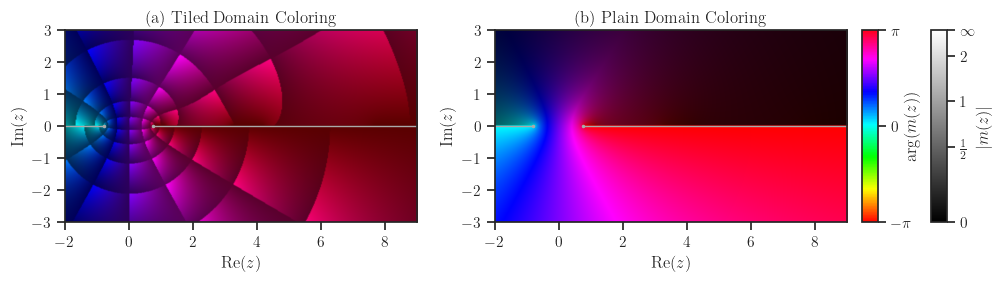

In [5]:
compare_domain_coloring(z, m1, roots_, support,
                        order='updown', sheet_idx=1,
                        latex=True, save=join(plot_dir, save_filename + '-domain-coloring.pdf'))

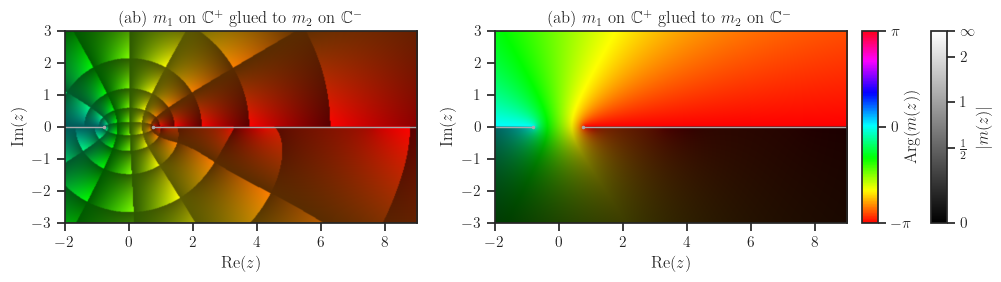

In [10]:
# compare_domain_coloring(z, m1, roots_, support,
#                         order='downup', sheet_idx=1,
#                         latex=True,
#                         latex=True, save=join(plot_dir, save_filename + '-domain-coloring.pdf'))